# Convergence of solid-body rotation

In this notebook we test how the accuracy of Parcels' advection kernels on an unstructured grid improves as we decrease the timestep `dt`. To isolate the error of the time integration, we use a flow with an exact solution: solid-body rotation, in which every particle moves on a circle at the same angular speed.

The recipe is:

1. Build a solid-body rotation velocity field on a triangular grid and load it into a `parcels.FieldSet`.
2. Release a line of particles and compute their exact (analytical) trajectories.
3. Advect the particles with RK2 and RK4 for a range of `dt`, and compare their final positions with the analytical solution.

In [1]:
import os

import numpy as np
import parcels
import uxarray as ux
from matplotlib import pyplot as plt
from matplotlib import tri
from parcels._datasets.unstructured.generated import solid_body_rotation_node_centered

In [2]:
u0 = 0.75
v0 = 0.75
w0 = 0.0075

lon_min, lon_max = 5.0, 10.0
lat_min, lat_max = 5.0, 10.0
H = 1000

## The solid-body rotation field

In solid-body rotation, the velocity increases linearly with distance from the rotation axis at the origin:

$$
u = -\Omega y, \qquad v = \Omega x,
$$

where $\Omega$ is the angular speed. We use $\Omega = 2\pi / 86400\ \text{s}^{-1}$, one full rotation per day.

Parcels ships a generator for this field, `solid_body_rotation_node_centered`, which triangulates a regular 40 × 40 lattice of points over $[-5, 5] \times [-5, 5]$ and places $u$ and $v$ on the triangle corners (nodes). The dataset has a single vertical layer and $w = 0$, so the problem is 2D.

The generator lives in `parcels._datasets`, which is a private module. It is convenient for testing, but its interface may change between Parcels versions.

In [3]:
ds = solid_body_rotation_node_centered(nx=40, omega=2 * np.pi / 86400)

## Build the `FieldSet`

Because $u$ and $v$ are registered on the nodes, Parcels picks the `UxLinearNodeConstantZC` interpolator, which interpolates barycentrically (linearly) within each triangle. The solid-body field is itself linear in $x$ and $y$, so we expect this inerpolation to be exact.

In [4]:
fieldset = parcels.FieldSet.from_ugrid_conventions(ds, mesh="flat")

## Release particles

We release 10 particles along the positive $x$-axis ($\theta_0 = 0$) at radii $R_0$ evenly spaced between 0.5 and 4.5.

In [5]:
theta0 = 0.0
R0 = np.linspace(0.5, 4.5, 10)
pset = parcels.ParticleSet(fieldset, x=R0 * np.cos(theta0), y=R0 * np.sin(theta0))

## Analytical solution

A particle starting at radius $R_0$ and angle $\theta_0$ moves on a circle:

$$
x(t) = R_0 \cos(\Omega t + \theta_0), \qquad y(t) = R_0 \sin(\Omega t + \theta_0).
$$

We evaluate this every 60 s over a runtime of 12 hours (43200 s), which is half a rotation.

In [6]:
omega = 2 * np.pi / 86400
t = np.arange(0, 0.5 * 86400 + 1, 60)
x_analytical = R0 * np.cos(omega * t[:, None] + theta0)
y_analytical = R0 * np.sin(omega * t[:, None] + theta0)

We plot the analytical trajectories on top of the grid (faint black lines), with the initial particle positions as dots in the matching colour.

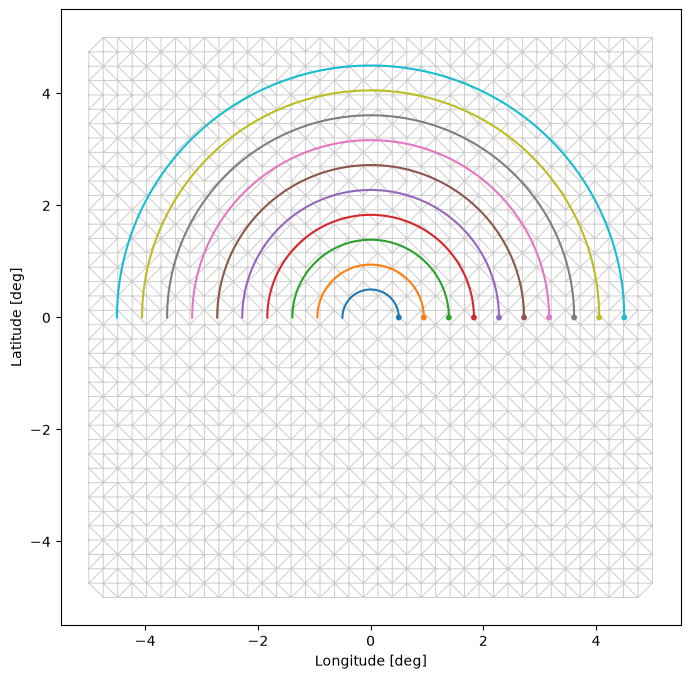

In [7]:
plt.figure(figsize=(8, 8))
grid = ds.uxgrid
plt.triplot(tri.Triangulation(grid.node_lon.values, grid.node_lat.values, grid.face_node_connectivity.values), color="k", alpha=0.2, linewidth=0.7)
lines = plt.plot(x_analytical, y_analytical)
plt.scatter(pset.x, pset.y, c=[line.get_color() for line in lines], s=10)
plt.xlabel("Longitude [deg]")
plt.ylabel("Latitude [deg]")
plt.show()

All particles sweep out half a circle over the 12 hour runtime. Particles further from the axis travel further, because the speed $\Omega R_0$ increases with radius.

## Convergence with RK2

Now we advect the particles with `parcels.kernels.AdvectionRK2` for five timesteps, halving `dt` from 960 s to 60 s. For each run we create a fresh `ParticleSet`, write the trajectories to a `parcels.ParticleFile` in the `parquet/` folder, and compute the error of each particle as the distance between its final position and the analytical one:

$$
\epsilon = \sqrt{(x - x_{\text{exact}})^2 + (y - y_{\text{exact}})^2}.
$$

**Note**: Parcels shortens a step so that it lands exactly on the next output time. If `outputdt` is smaller than `dt` a run uses `dt = outputdt`.

In [8]:
os.makedirs("parquet", exist_ok=True)

In [9]:
dts, errors = [960, 480, 240, 120, 60], []
for dt_s in dts:
    pset = parcels.ParticleSet(fieldset, x=R0 * np.cos(theta0), y=R0 * np.sin(theta0))
    output_file = parcels.ParticleFile(f"parquet/solid-body-rotation-dt{dt_s}.parquet", outputdt=np.timedelta64(960, "s"), mode="w")
    pset.execute(parcels.kernels.AdvectionRK2, runtime=np.timedelta64(43200, "s"), dt=np.timedelta64(dt_s, "s"), output_file=output_file)
    errors.append(np.hypot(pset.x - x_analytical[-1], pset.y - y_analytical[-1]))

INFO: Output files are stored in parquet/solid-body-rotation-dt960.parquet
Integration time: 42240 seconds 100%|███████████| [00:00<00:00, 109360.82it/s]
INFO: Output files are stored in parquet/solid-body-rotation-dt480.parquet
Integration time: 42240 seconds 100%|████████████| [00:00<00:00, 72017.78it/s]
INFO: Output files are stored in parquet/solid-body-rotation-dt240.parquet
Integration time: 42240 seconds 100%|████████████| [00:01<00:00, 37467.61it/s]
INFO: Output files are stored in parquet/solid-body-rotation-dt120.parquet
Integration time: 42240 seconds 100%|████████████| [00:02<00:00, 19737.89it/s]
INFO: Output files are stored in parquet/solid-body-rotation-dt60.parquet
Integration time: 42240 seconds 100%|████████████| [00:04<00:00, 10225.13it/s]


We plot the error of each particle against `dt` on a logarithmic error axis, together with a reference line proportional to $\text{d}t^2$ (the expected convergence rate for the RK2 scheme).

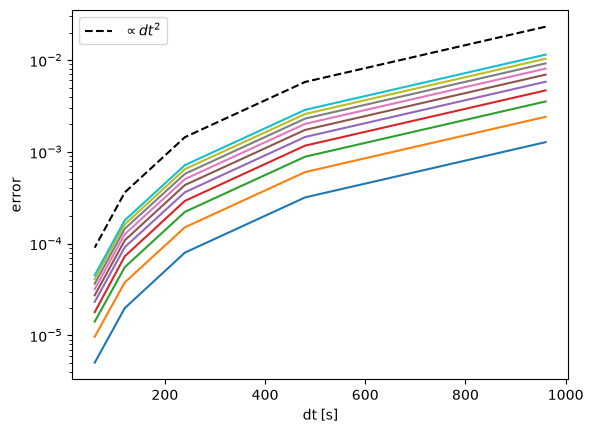

In [10]:
plt.semilogy(dts, errors)
plt.semilogy(dts, 2 * errors[-1].max() * (np.array(dts) / dts[-1]) ** 2, "k--", label=r"$\propto dt^2$")
plt.legend()
plt.xlabel("dt [s]")
plt.ylabel("error")
plt.show()

The errors of all particles fall parallel to the $\text{d}t^2$ line: halving `dt` reduces the error by a factor of 4, as expected for the second-order RK2 scheme. The error is larger for particles at larger radius, because they travel further per step.

## Convergence with RK4

`parcels.kernels.AdvectionRK4` is fourth order, so at the timesteps in the RK2 example its error is already at the level of floating-point round-off. Parcels stores particle positions as `float32`, which has a relative precision of about $10^{-7}$. To see the fourth-order convergence we need much larger timesteps, so we halve `dt` from 10800 s (3 hours) down to 675 s.

In [11]:
dts_rk4, errors_rk4 = [10800, 5400, 2700, 1350, 675], []
for dt_s in dts_rk4:
    pset = parcels.ParticleSet(fieldset, x=R0 * np.cos(theta0), y=R0 * np.sin(theta0))
    output_file = parcels.ParticleFile(f"parquet/solid-body-rotation-rk4-dt{dt_s}.parquet", outputdt=np.timedelta64(10800, "s"), mode="w")
    pset.execute(parcels.kernels.AdvectionRK4, runtime=np.timedelta64(43200, "s"), dt=np.timedelta64(dt_s, "s"), output_file=output_file)
    errors_rk4.append(np.hypot(pset.x - x_analytical[-1], pset.y - y_analytical[-1]))

INFO: Output files are stored in parquet/solid-body-rotation-rk4-dt10800.parquet
Integration time: 32400 seconds 100%|███████████| [00:00<00:00, 739075.36it/s]
INFO: Output files are stored in parquet/solid-body-rotation-rk4-dt5400.parquet
Integration time: 32400 seconds 100%|███████████| [00:00<00:00, 387247.61it/s]
INFO: Output files are stored in parquet/solid-body-rotation-rk4-dt2700.parquet
Integration time: 32400 seconds 100%|███████████| [00:00<00:00, 217548.46it/s]
INFO: Output files are stored in parquet/solid-body-rotation-rk4-dt1350.parquet
Integration time: 32400 seconds 100%|███████████| [00:00<00:00, 110867.07it/s]
INFO: Output files are stored in parquet/solid-body-rotation-rk4-dt675.parquet
Integration time: 32400 seconds 100%|████████████| [00:00<00:00, 56690.42it/s]


We plot the RK4 errors in the same way, now with a reference line proportional to $\text{d}t^4$.

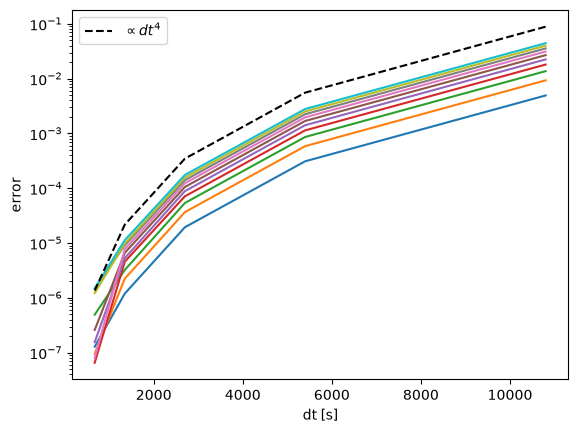

In [12]:
plt.semilogy(dts_rk4, errors_rk4)
plt.semilogy(dts_rk4, 2 * errors_rk4[0].max() * (np.array(dts_rk4) / dts_rk4[0]) ** 4, "k--", label=r"$\propto dt^4$")
plt.legend()
plt.xlabel("dt [s]")
plt.ylabel("error")
plt.show()

For the larger timesteps the errors fall parallel to the $\text{d}t^4$ line as expected, halving `dt` reduces the error by a factor of 16. At the smallest timestep the decrease slows down because the error approaches the `float32` round-off level (around $10^{-6}$). Near this floor, all of the particle errors are roughly equal regardless of their speed.